# Multi-Omics Cancer Classification: Early & Late Fusion Pipeline

**Project:** Classify 6 TCGA cancer types (BRCA, COAD, KIRC, LIHC, LUAD, THCA) from BulkFormer (RNA-seq, 643-dim) and CpGPT (methylation, 128-dim) foundation-model embeddings.

**Methods:**
- 5 fusion strategies: BulkFormer only, CpGPT only, Early fusion (z-score + PCA-equalized), Late fusion (probability averaging), Late fusion (learned weighting)
- 3 classifiers: Linear probe (Logistic Regression), RBF-SVM, XGBoost
- Nested cross-validation: 5-fold outer (evaluation) × 3-fold inner (hyperparameter tuning)
- All preprocessing fit on train folds only (no leakage)

**Inputs required:**
- `bulkformer_embeddings.npy` — shape (800, 643)
- `cpgpt_embeddings.npy` — shape (800, 128)
- Labels: alphabetical block order BRCA(134), COAD(133), KIRC(133), LIHC(133), LUAD(134), THCA(133)

**Estimated runtime:** ~30-40 minutes on a modern laptop.

## 0. Setup

In [1]:
# Install required packages (uncomment if needed)
# !pip install numpy pandas scikit-learn xgboost shap matplotlib seaborn scipy

In [2]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
import xgboost as xgb

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuration
N_OUTER = 5
N_INNER = 3
PCA_K = 64

# Output directory (edit if running locally)
OUTDIR = '/Users/sani/Desktop/rudarenje/multi-omics-cancer-classification/results'
os.makedirs(OUTDIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load Embeddings and Build Labels

Labels are derived from the **alphabetical block order** of TCGA project folders, confirmed against `matched_samples.csv`:
- BRCA: rows 0–133 (134 samples)
- COAD: rows 134–266 (133 samples)
- KIRC: rows 267–399 (133 samples)
- LIHC: rows 400–532 (133 samples)
- LUAD: rows 533–666 (134 samples)
- THCA: rows 667–799 (133 samples)

**If your embeddings use a different ordering, edit the `sizes` list below.**

In [3]:
# Set these to the local paths to your embedding files
BULKFORMER_PATH = '/Users/sani/Desktop/rudarenje/multi-omics-cancer-classification/data/processed/bulkformer_embeddings.npy'
CPGPT_PATH = '/Users/sani/Desktop/rudarenje/multi-omics-cancer-classification/data/processed/cpgpt_embeddings.npy'

bulkformer = np.load(BULKFORMER_PATH)
cpgpt = np.load(CPGPT_PATH)

print(f'BulkFormer: {bulkformer.shape}, dtype={bulkformer.dtype}')
print(f'CpGPT:      {cpgpt.shape}, dtype={cpgpt.dtype}')

# Sanity checks
assert bulkformer.shape == (800, 643), 'Expected BulkFormer (800, 643)'
assert cpgpt.shape == (800, 128), 'Expected CpGPT (800, 128)'
assert not np.isnan(bulkformer).any() and not np.isinf(bulkformer).any()
assert not np.isnan(cpgpt).any() and not np.isinf(cpgpt).any()
print('Embeddings loaded and validated.')

BulkFormer: (800, 643), dtype=float32
CpGPT:      (800, 128), dtype=float32
Embeddings loaded and validated.


In [4]:
cancer_types = ['BRCA', 'COAD', 'KIRC', 'LIHC', 'LUAD', 'THCA']
sizes        = [   134,    133,    133,    133,    134,    133]
assert sum(sizes) == 800

labels_raw = np.concatenate([np.full(sz, ct) for ct, sz in zip(cancer_types, sizes)])
le = LabelEncoder()
y = le.fit_transform(labels_raw)
n_classes = len(le.classes_)
class_names = list(le.classes_)

print('Class distribution:')
for i, name in enumerate(class_names):
    print(f'  {name}: {int((y == i).sum())} samples (label index {i})')

Class distribution:
  BRCA: 134 samples (label index 0)
  COAD: 133 samples (label index 1)
  KIRC: 133 samples (label index 2)
  LIHC: 133 samples (label index 3)
  LUAD: 134 samples (label index 4)
  THCA: 133 samples (label index 5)


## 2. Pipeline Components

### Modality processor (z-score + PCA, fit on train only)

In [5]:
class ModalityProcessor:
    """Z-score + PCA per modality. Fits only on training data to prevent leakage."""
    def __init__(self, n_components=PCA_K, name='modality'):
        self.n_components = n_components
        self.name = name
        self.scaler = StandardScaler()
        self.pca = None
        self.explained_var = None

    def fit_transform(self, X):
        Xs = self.scaler.fit_transform(X)
        n_comp = min(self.n_components, X.shape[1], X.shape[0])
        self.pca = PCA(n_components=n_comp, random_state=RANDOM_SEED)
        Xp = self.pca.fit_transform(Xs)
        self.explained_var = self.pca.explained_variance_ratio_.sum()
        return Xp

    def transform(self, X):
        return self.pca.transform(self.scaler.transform(X))

### Classifier factories and hyperparameter tuning

In [6]:
# Hyperparameter grids (kept tight to control runtime)
GRID_LOGREG = {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0]}
GRID_SVM = {
    'clf__C': [0.1, 1.0, 10.0, 100.0],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01],
}
GRID_XGB = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 8],
    'learning_rate': [0.05, 0.1],
}

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000,
                                    random_state=RANDOM_SEED)),
    ])

def make_svm():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)),
    ])

def make_xgb(n_classes):
    return xgb.XGBClassifier(
        objective='multi:softprob', num_class=n_classes,
        eval_metric='mlogloss', tree_method='hist',
        random_state=RANDOM_SEED, n_jobs=1, verbosity=0,
    )

def tune_clf(name, n_classes, X_train, y_train, inner_cv):
    """Inner CV hyperparameter tuning. Returns best fitted estimator + params."""
    if name == 'LogReg':
        base, grid = make_logreg(), GRID_LOGREG
    elif name == 'SVM':
        base, grid = make_svm(), GRID_SVM
    elif name == 'XGBoost':
        base, grid = make_xgb(n_classes), GRID_XGB
    else:
        raise ValueError(name)
    gs = GridSearchCV(base, grid, cv=inner_cv, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train, y_train)
    return gs.best_estimator_, gs.best_params_

def compute_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    try:
        auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc = np.nan
    return {'accuracy': acc, 'f1_macro': f1m, 'auc_macro': auc}

## 3. Nested Cross-Validation

For each outer fold:
1. Split into train (640) and test (160)
2. For each classifier (LogReg, SVM, XGBoost):
   - Tune on **BulkFormer only** (inner 3-fold CV) → predict on test
   - Tune on **CpGPT only** → predict on test
   - Tune on **Early fusion** (z-score + PCA(64) per modality, concatenated) → predict on test
   - **Late-Avg** = average of per-modality probabilities
   - **Late-Learned** = logistic meta-learner on cross-validated per-modality probabilities

Total fits per outer fold: 3 classifiers × 3 grid searches + meta-learners = ~moderately heavy

In [7]:
outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_SEED)
inner_cv = StratifiedKFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_SEED)

classifiers = ['LogReg', 'SVM', 'XGBoost']
fusion_configs = ['BulkFormer', 'CpGPT', 'EarlyFusion', 'LateFusion_Avg', 'LateFusion_Learned']

# Storage
N = len(y)
per_fold_records = []
explained_var_records = []
best_params_records = []
oof_preds = {(f, c): {'y_pred': np.full(N, -1, dtype=int),
                       'y_proba': np.zeros((N, n_classes))}
             for f in fusion_configs for c in classifiers}

t0_total = time.time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(np.zeros(N), y)):
    print(f'\n{"="*60}\nOUTER FOLD {fold_idx+1}/{N_OUTER}  '
          f'(train={len(train_idx)}, test={len(test_idx)})\n{"="*60}')
    
    Xb_tr, Xb_te = bulkformer[train_idx], bulkformer[test_idx]
    Xc_tr, Xc_te = cpgpt[train_idx], cpgpt[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # Early Fusion: z-score + PCA per modality, fit on TRAIN only
    proc_b = ModalityProcessor(PCA_K, 'BulkFormer')
    proc_c = ModalityProcessor(PCA_K, 'CpGPT')
    Xb_tr_p = proc_b.fit_transform(Xb_tr); Xb_te_p = proc_b.transform(Xb_te)
    Xc_tr_p = proc_c.fit_transform(Xc_tr); Xc_te_p = proc_c.transform(Xc_te)
    Xearly_tr = np.hstack([Xb_tr_p, Xc_tr_p])
    Xearly_te = np.hstack([Xb_te_p, Xc_te_p])
    explained_var_records.append({'fold': fold_idx,
                                   'bulkformer_ev': proc_b.explained_var,
                                   'cpgpt_ev': proc_c.explained_var})
    print(f'  PCA EV: BulkFormer={proc_b.explained_var:.3f}, CpGPT={proc_c.explained_var:.3f}')
    
    for clf_name in classifiers:
        t0 = time.time()
        # 1. BulkFormer
        est_b, bp_b = tune_clf(clf_name, n_classes, Xb_tr, y_tr, inner_cv)
        proba_b_te = est_b.predict_proba(Xb_te)
        y_pred_b = est_b.predict(Xb_te)
        oof_preds[('BulkFormer', clf_name)]['y_pred'][test_idx] = y_pred_b
        oof_preds[('BulkFormer', clf_name)]['y_proba'][test_idx] = proba_b_te
        per_fold_records.append({'fusion': 'BulkFormer', 'classifier': clf_name,
                                 'fold': fold_idx, **compute_metrics(y_te, y_pred_b, proba_b_te)})
        
        # 2. CpGPT
        est_c, bp_c = tune_clf(clf_name, n_classes, Xc_tr, y_tr, inner_cv)
        proba_c_te = est_c.predict_proba(Xc_te)
        y_pred_c = est_c.predict(Xc_te)
        oof_preds[('CpGPT', clf_name)]['y_pred'][test_idx] = y_pred_c
        oof_preds[('CpGPT', clf_name)]['y_proba'][test_idx] = proba_c_te
        per_fold_records.append({'fusion': 'CpGPT', 'classifier': clf_name,
                                 'fold': fold_idx, **compute_metrics(y_te, y_pred_c, proba_c_te)})
        
        # 3. Early fusion
        est_e, bp_e = tune_clf(clf_name, n_classes, Xearly_tr, y_tr, inner_cv)
        proba_e_te = est_e.predict_proba(Xearly_te)
        y_pred_e = est_e.predict(Xearly_te)
        oof_preds[('EarlyFusion', clf_name)]['y_pred'][test_idx] = y_pred_e
        oof_preds[('EarlyFusion', clf_name)]['y_proba'][test_idx] = proba_e_te
        per_fold_records.append({'fusion': 'EarlyFusion', 'classifier': clf_name,
                                 'fold': fold_idx, **compute_metrics(y_te, y_pred_e, proba_e_te)})
        
        # 4. Late fusion - averaging
        proba_avg = 0.5 * (proba_b_te + proba_c_te)
        y_pred_avg = proba_avg.argmax(axis=1)
        oof_preds[('LateFusion_Avg', clf_name)]['y_pred'][test_idx] = y_pred_avg
        oof_preds[('LateFusion_Avg', clf_name)]['y_proba'][test_idx] = proba_avg
        per_fold_records.append({'fusion': 'LateFusion_Avg', 'classifier': clf_name,
                                 'fold': fold_idx, **compute_metrics(y_te, y_pred_avg, proba_avg)})
        
        # 5. Late fusion - learned (meta-learner trained on OOF train probabilities)
        meta_b_tr = cross_val_predict(est_b, Xb_tr, y_tr, cv=inner_cv, method='predict_proba', n_jobs=1)
        meta_c_tr = cross_val_predict(est_c, Xc_tr, y_tr, cv=inner_cv, method='predict_proba', n_jobs=1)
        meta_X_tr = np.hstack([meta_b_tr, meta_c_tr])
        meta_learner = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                          max_iter=2000, random_state=RANDOM_SEED)
        meta_learner.fit(meta_X_tr, y_tr)
        meta_X_te = np.hstack([proba_b_te, proba_c_te])
        proba_learned = meta_learner.predict_proba(meta_X_te)
        y_pred_learned = meta_learner.predict(meta_X_te)
        oof_preds[('LateFusion_Learned', clf_name)]['y_pred'][test_idx] = y_pred_learned
        oof_preds[('LateFusion_Learned', clf_name)]['y_proba'][test_idx] = proba_learned
        per_fold_records.append({'fusion': 'LateFusion_Learned', 'classifier': clf_name,
                                 'fold': fold_idx, **compute_metrics(y_te, y_pred_learned, proba_learned)})
        
        best_params_records.append({'fold': fold_idx, 'classifier': clf_name,
                                     'bulkformer_params': json.dumps(bp_b),
                                     'cpgpt_params': json.dumps(bp_c),
                                     'early_params': json.dumps(bp_e)})
        print(f'    {clf_name}: {time.time()-t0:.1f}s')

print(f'\nTotal runtime: {(time.time()-t0_total)/60:.1f} min')


OUTER FOLD 1/5  (train=640, test=160)
  PCA EV: BulkFormer=0.987, CpGPT=0.997


    LogReg: 2.9s


    SVM: 2.9s


    XGBoost: 81.6s

OUTER FOLD 2/5  (train=640, test=160)
  PCA EV: BulkFormer=0.987, CpGPT=0.997


    LogReg: 0.6s


...

    SVM: 5.0s


    XGBoost: 157.4s

OUTER FOLD 5/5  (train=640, test=160)
  PCA EV: BulkFormer=0.987, CpGPT=0.997


    LogReg: 1.6s


    SVM: 5.1s


    XGBoost: 158.8s

Total runtime: 9.9 min


## 4. Aggregate Results

In [8]:
per_fold_df = pd.DataFrame(per_fold_records)
per_fold_df.to_csv(f'{OUTDIR}/per_fold_metrics.csv', index=False)

summary = (per_fold_df.groupby(['fusion', 'classifier'])
           .agg(accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
                f1_mean=('f1_macro', 'mean'), f1_std=('f1_macro', 'std'),
                auc_mean=('auc_macro', 'mean'), auc_std=('auc_macro', 'std'))
           .reset_index())
summary.to_csv(f'{OUTDIR}/results_summary.csv', index=False)

# Pretty print
summary_display = summary.copy()
for col in ['accuracy', 'f1', 'auc']:
    summary_display[col] = (summary[f'{col}_mean'].round(4).astype(str) + ' ± '
                            + summary[f'{col}_std'].round(4).astype(str))
print(summary_display[['fusion', 'classifier', 'accuracy', 'f1', 'auc']].to_string(index=False))

            fusion classifier        accuracy              f1             auc
        BulkFormer     LogReg  0.985 ± 0.0095  0.985 ± 0.0095  0.998 ± 0.0029
        BulkFormer        SVM 0.9875 ± 0.0063 0.9875 ± 0.0062  0.998 ± 0.0027
        BulkFormer    XGBoost   0.98 ± 0.0052   0.98 ± 0.0052 0.9972 ± 0.0033
             CpGPT     LogReg   0.87 ± 0.0209 0.8702 ± 0.0219 0.9809 ± 0.0043
             CpGPT        SVM 0.8775 ± 0.0311 0.8774 ± 0.0313 0.9807 ± 0.0049
             CpGPT    XGBoost 0.8012 ± 0.0425 0.8007 ± 0.0414  0.962 ± 0.0105
       EarlyFusion     LogReg 0.9887 ± 0.0093 0.9888 ± 0.0092  0.998 ± 0.0029
       EarlyFusion        SVM   0.99 ± 0.0056   0.99 ± 0.0056  0.998 ± 0.0031
       EarlyFusion    XGBoost 0.9712 ± 0.0034 0.9711 ± 0.0035 0.9976 ± 0.0026
    LateFusion_Avg     LogReg  0.975 ± 0.0088 0.9751 ± 0.0087 0.9977 ± 0.0028
    LateFusion_Avg        SVM 0.9825 ± 0.0052 0.9826 ± 0.0052  0.998 ± 0.0025
    LateFusion_Avg    XGBoost   0.96 ± 0.0219   0.96 ± 0.0219 0.

In [9]:
# Per-class metrics on OOF predictions
per_class_rows = []
for (fusion, clf), preds in oof_preds.items():
    yp = preds['y_pred']
    p, r, f, s = precision_recall_fscore_support(y, yp, labels=range(n_classes), zero_division=0)
    df = pd.DataFrame({'class': class_names, 'precision': p, 'recall': r, 'f1': f, 'support': s})
    df['fusion'] = fusion; df['classifier'] = clf
    per_class_rows.append(df)
per_class_df = pd.concat(per_class_rows, ignore_index=True)
per_class_df = per_class_df[['fusion', 'classifier', 'class', 'precision', 'recall', 'f1', 'support']]
per_class_df.to_csv(f'{OUTDIR}/per_class_metrics.csv', index=False)
per_class_df.head(18)

,fusion,classifier,class,precision,recall,f1,support
0,BulkFormer,LogReg,BRCA,0.977778,0.985075,0.981413,134
1,BulkFormer,LogReg,COAD,0.970588,0.992481,0.981413,133
2,BulkFormer,LogReg,KIRC,0.992366,0.977444,0.984848,133
3,BulkFormer,LogReg,LIHC,0.970149,0.977444,0.973783,133
4,BulkFormer,LogReg,LUAD,1.000000,0.992537,0.996255,134
5,BulkFormer,LogReg,THCA,1.000000,0.984962,0.992424,133
6,BulkFormer,SVM,BRCA,0.971014,1.000000,0.985294,134
7,BulkFormer,SVM,COAD,0.977612,0.984962,0.981273,133
8,BulkFormer,SVM,KIRC,0.992424,0.984962,0.988679,133
9,BulkFormer,SVM,LIHC,0.984733,0.969925,0.977273,133


## 5. Statistical Comparison Between Methods

- **Paired Wilcoxon signed-rank test:** compares per-fold scores (5 paired observations).
- **McNemar's test:** compares per-sample predictions (OOF, n=800).

In [10]:
def wilcoxon_pairs(per_fold_df, metric='f1_macro'):
    """Pairwise Wilcoxon across outer folds for each metric."""
    pivot = per_fold_df.pivot_table(index='fold',
                                     columns=['fusion', 'classifier'],
                                     values=metric)
    configs = list(pivot.columns)
    rows = []
    for i, ca in enumerate(configs):
        for cb in configs[i+1:]:
            a = pivot[ca].values; b = pivot[cb].values
            if np.allclose(a, b):
                stat, p = np.nan, 1.0
            else:
                try:
                    stat, p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
                except Exception:
                    stat, p = np.nan, np.nan
            rows.append({'config_A': '__'.join(ca), 'config_B': '__'.join(cb),
                         'mean_diff': a.mean() - b.mean(), 'p_value': p})
    return pd.DataFrame(rows).sort_values('p_value')

wilcoxon_df = wilcoxon_pairs(per_fold_df, metric='f1_macro')
wilcoxon_df.to_csv(f'{OUTDIR}/wilcoxon_pairwise_f1.csv', index=False)
print('Top 10 most-significant pairwise Wilcoxon comparisons (macro F1):')
print(wilcoxon_df.head(10).to_string(index=False))

Top 10 most-significant pairwise Wilcoxon comparisons (macro F1):
     config_A                    config_B  mean_diff  p_value
   CpGPT__SVM            EarlyFusion__SVM  -0.112620   0.0625
   CpGPT__SVM        EarlyFusion__XGBoost  -0.093752   0.0625
   CpGPT__SVM         EarlyFusion__LogReg  -0.111411   0.0625
   CpGPT__SVM              CpGPT__XGBoost   0.076703   0.0625
CpGPT__LogReg LateFusion_Learned__XGBoost  -0.112267   0.0625
CpGPT__LogReg     LateFusion_Learned__SVM  -0.116055   0.0625
CpGPT__LogReg  LateFusion_Learned__LogReg  -0.119768   0.0625
   CpGPT__SVM      LateFusion_Avg__LogReg  -0.097751   0.0625
CpGPT__LogReg     LateFusion_Avg__XGBoost  -0.089797   0.0625
CpGPT__LogReg      LateFusion_Avg__LogReg  -0.104900   0.0625


In [11]:
def mcnemar_pairs(oof_preds, y_true):
    """Pairwise McNemar's test on out-of-fold predictions."""
    configs = list(oof_preds.keys())
    rows = []
    for i, ca in enumerate(configs):
        for cb in configs[i+1:]:
            yp_a = oof_preds[ca]['y_pred']
            yp_b = oof_preds[cb]['y_pred']
            correct_a = (yp_a == y_true)
            correct_b = (yp_b == y_true)
            b = int(((correct_a) & (~correct_b)).sum())  # A correct, B wrong
            c = int(((~correct_a) & (correct_b)).sum())  # A wrong, B correct
            table = [[0, b], [c, 0]]
            try:
                res = mcnemar(table, exact=(b + c < 25), correction=True)
                p = res.pvalue
            except Exception:
                p = np.nan
            rows.append({'config_A': f'{ca[0]}_{ca[1]}', 'config_B': f'{cb[0]}_{cb[1]}',
                         'A_correct_B_wrong': b, 'A_wrong_B_correct': c, 'p_value': p})
    return pd.DataFrame(rows).sort_values('p_value')

mcnemar_df = mcnemar_pairs(oof_preds, y)
mcnemar_df.to_csv(f'{OUTDIR}/mcnemar_pairwise.csv', index=False)
print('Top 10 most-significant pairwise McNemar tests:')
print(mcnemar_df.head(10).to_string(index=False))

Top 10 most-significant pairwise McNemar tests:
          config_A                   config_B  A_correct_B_wrong  A_wrong_B_correct      p_value
     CpGPT_XGBoost         EarlyFusion_LogReg                  0                150 4.727960e-34
     CpGPT_XGBoost            EarlyFusion_SVM                  1                152 7.618547e-34
     CpGPT_XGBoost  LateFusion_Learned_LogReg                  2                153 1.980154e-33
    BulkFormer_SVM              CpGPT_XGBoost                150                  1 2.084157e-33
     CpGPT_XGBoost     LateFusion_Learned_SVM                  1                149 3.447250e-33
     CpGPT_XGBoost         LateFusion_Avg_SVM                  0                145 5.857645e-33
 BulkFormer_LogReg              CpGPT_XGBoost                150                  3 3.748516e-32
     CpGPT_XGBoost LateFusion_Learned_XGBoost                  3                148 1.024052e-31
     CpGPT_XGBoost      LateFusion_Avg_LogReg                  1               

## 6. Visualization

### 6a. Bar plot: macro F1 across methods

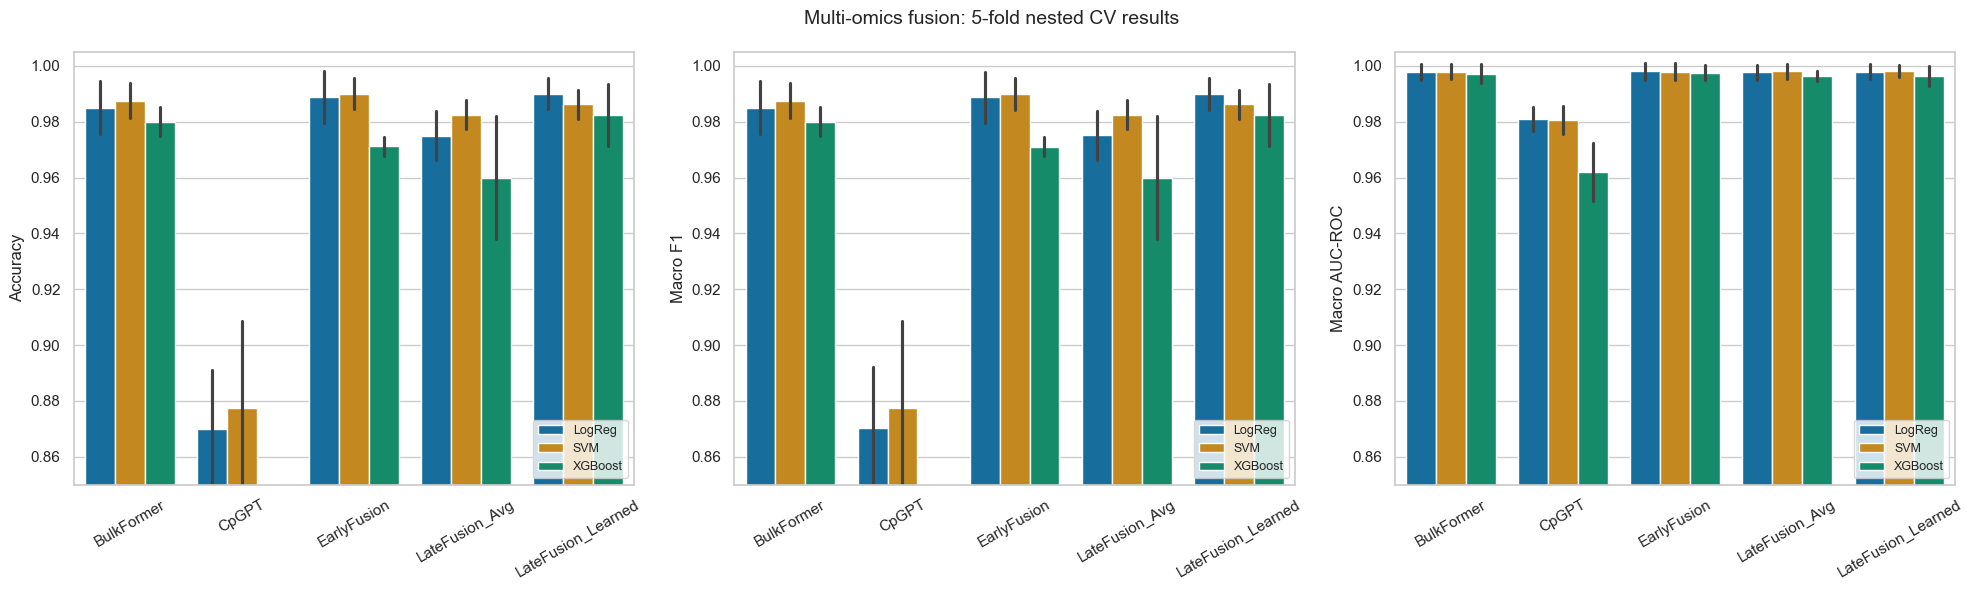

In [12]:
sns.set_context('notebook'); sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric, ylabel in zip(axes,
                                ['accuracy', 'f1_macro', 'auc_macro'],
                                ['Accuracy', 'Macro F1', 'Macro AUC-ROC']):
    sns.barplot(data=per_fold_df, x='fusion', y=metric, hue='classifier', ax=ax,
                errorbar='sd', palette='colorblind')
    ax.set_ylabel(ylabel); ax.set_xlabel('')
    ax.set_ylim(0.85, 1.005)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='lower right', fontsize=9)
plt.suptitle('Multi-omics fusion: 5-fold nested CV results', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/metrics_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 6b. Confusion matrices grid

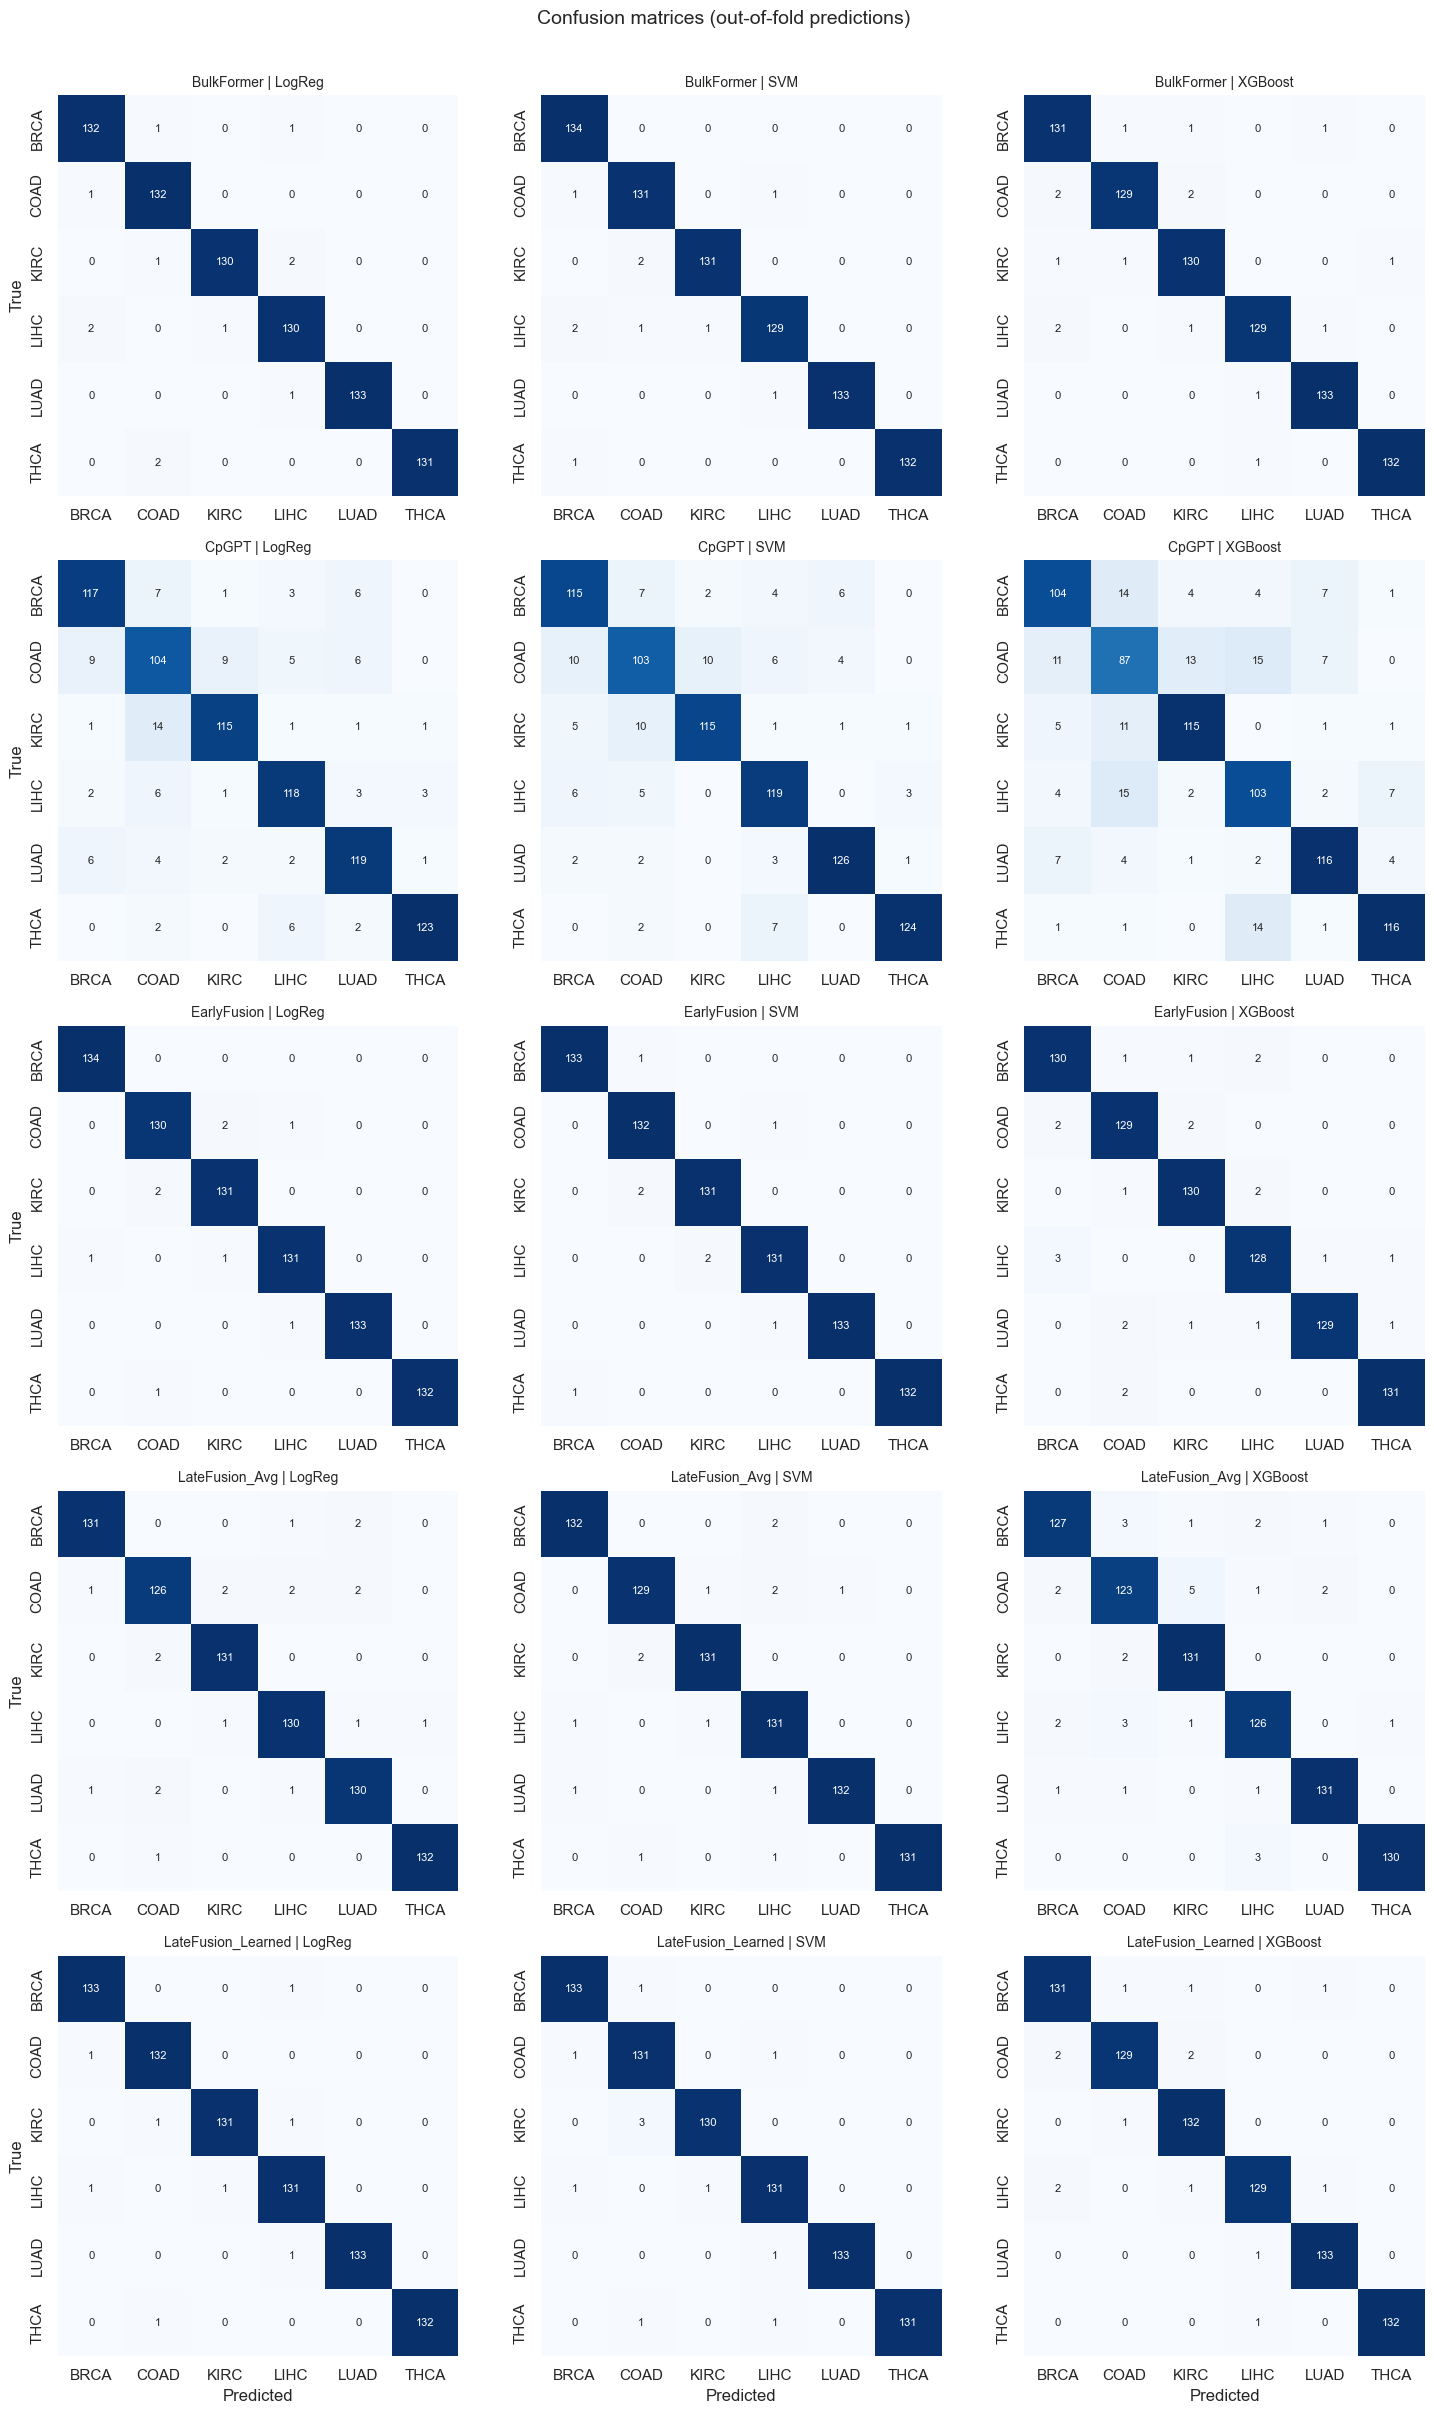

In [13]:
fig, axes = plt.subplots(len(fusion_configs), len(classifiers),
                          figsize=(15, 24))
for i, fusion in enumerate(fusion_configs):
    for j, clf in enumerate(classifiers):
        ax = axes[i, j]
        cm = confusion_matrix(y, oof_preds[(fusion, clf)]['y_pred'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    cbar=False, square=True, annot_kws={'size': 8})
        ax.set_title(f'{fusion} | {clf}', fontsize=10)
        ax.set_xlabel('Predicted' if i == len(fusion_configs)-1 else '')
        ax.set_ylabel('True' if j == 0 else '')
plt.suptitle('Confusion matrices (out-of-fold predictions)', y=1.005, fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Interpretation (Early Fusion + XGBoost)

Train a single XGBoost on the full dataset using the early-fusion features (PCA components), then run SHAP to identify the most discriminative components — and which modality they came from.

In [14]:
import shap

# Fit modality processors on the full dataset (interpretation only — not for evaluation)
proc_b_full = ModalityProcessor(PCA_K, 'BulkFormer'); Xb_full = proc_b_full.fit_transform(bulkformer)
proc_c_full = ModalityProcessor(PCA_K, 'CpGPT');      Xc_full = proc_c_full.fit_transform(cpgpt)
X_early_full = np.hstack([Xb_full, Xc_full])

# Feature names: PC1..PC64 per modality
feat_names = [f'BulkFormer_PC{i+1}' for i in range(PCA_K)] + [f'CpGPT_PC{i+1}' for i in range(PCA_K)]

# Train XGBoost (use median best hyperparams across folds — read from best_params_records)
from collections import Counter
xgb_params_chosen = [json.loads(r['early_params']) for r in best_params_records if r['classifier'] == 'XGBoost']
param_counts = Counter(tuple(sorted(p.items())) for p in xgb_params_chosen)
best_xgb_params = dict(param_counts.most_common(1)[0][0])
print('Using most-common XGBoost params across folds:', best_xgb_params)

model = make_xgb(n_classes).set_params(**best_xgb_params)
model.fit(X_early_full, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_early_full)
if isinstance(shap_values, list):
    # one (n, p) matrix per class
    shap_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n, p)
else:
    # (n, p, n_classes)
    shap_abs = np.abs(shap_values).mean(axis=-1)

mean_abs_shap = shap_abs.mean(axis=0)  # (p,)
shap_importance = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs_shap})
shap_importance['modality'] = shap_importance['feature'].str.split('_').str[0]
shap_importance = shap_importance.sort_values('mean_abs_shap', ascending=False)

shap_importance.to_csv(f'{OUTDIR}/shap_feature_importance.csv', index=False)

# Modality-level summary
modality_sums = shap_importance.groupby('modality')['mean_abs_shap'].sum()
modality_pct = modality_sums / modality_sums.sum() * 100
print(f'\nModality contribution to predictions:')
for m, pct in modality_pct.items():
    print(f'  {m}: {pct:.1f}%')

Using most-common XGBoost params across folds: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}



Modality contribution to predictions:
  BulkFormer: 86.3%
  CpGPT: 13.7%


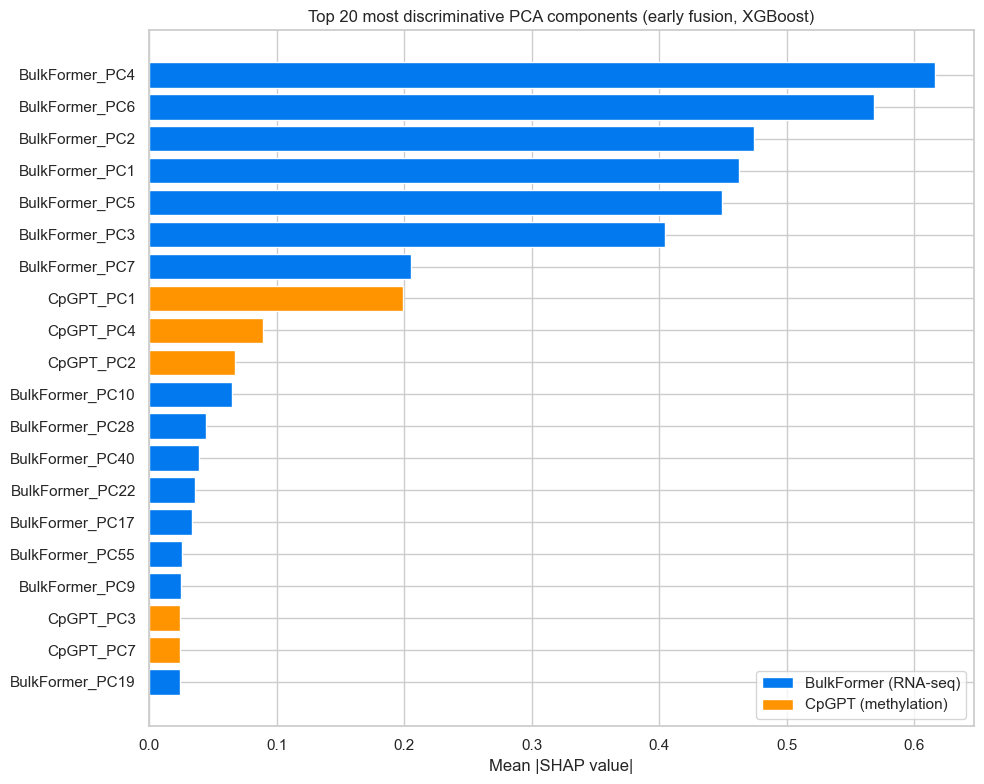

In [15]:
# Plot top features colored by modality
fig, ax = plt.subplots(figsize=(10, 8))
top20 = shap_importance.head(20)
colors = top20['modality'].map({'BulkFormer': '#0279EE', 'CpGPT': '#FF9400'})
ax.barh(range(len(top20)), top20['mean_abs_shap'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 most discriminative PCA components (early fusion, XGBoost)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#0279EE', label='BulkFormer (RNA-seq)'),
                   Patch(facecolor='#FF9400', label='CpGPT (methylation)')])
plt.tight_layout()
plt.savefig(f'{OUTDIR}/shap_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

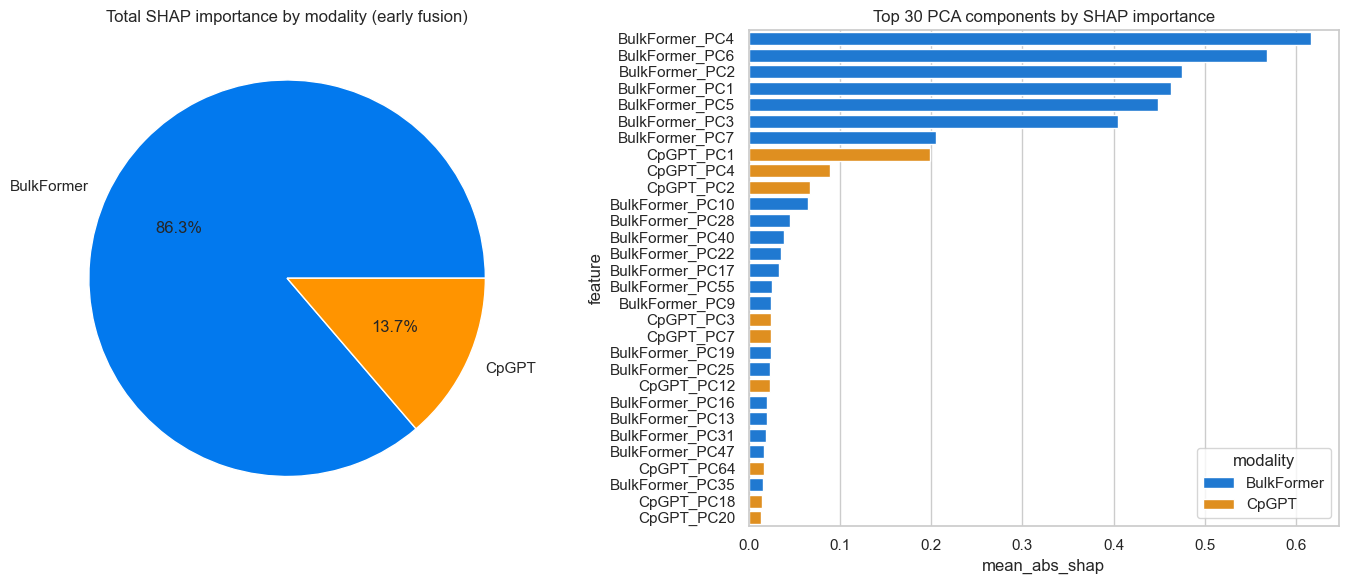

In [16]:
# Modality contribution pie/bar
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Pie
ax[0].pie(modality_sums.values, labels=modality_sums.index, autopct='%.1f%%',
          colors=['#0279EE', '#FF9400'])
ax[0].set_title('Total SHAP importance by modality (early fusion)')

# Bar
sns.barplot(data=shap_importance.head(30), x='mean_abs_shap', y='feature',
            hue='modality', dodge=False, palette={'BulkFormer': '#0279EE', 'CpGPT': '#FF9400'},
            ax=ax[1])
ax[1].set_title('Top 30 PCA components by SHAP importance')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/shap_modality_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Out-of-Fold Predictions

These are needed if you (or your colleague's deep-fusion arm) want to do further analysis.

In [17]:
np.savez(
    f'{OUTDIR}/oof_predictions.npz',
    y_true=y,
    class_names=np.array(class_names),
    **{f'{fusion}__{clf}__pred': oof_preds[(fusion, clf)]['y_pred']
       for fusion in fusion_configs for clf in classifiers},
    **{f'{fusion}__{clf}__proba': oof_preds[(fusion, clf)]['y_proba']
       for fusion in fusion_configs for clf in classifiers},
)
print(f'Saved out-of-fold predictions to {OUTDIR}/oof_predictions.npz')

pd.DataFrame(explained_var_records).to_csv(f'{OUTDIR}/pca_explained_variance.csv', index=False)
pd.DataFrame(best_params_records).to_csv(f'{OUTDIR}/best_params_per_fold.csv', index=False)
print('All outputs saved to:', OUTDIR)

Saved out-of-fold predictions to /Users/sani/Desktop/rudarenje/multi-omics-cancer-classification/results/oof_predictions.npz
All outputs saved to: /Users/sani/Desktop/rudarenje/multi-omics-cancer-classification/results


## Outputs Summary

All files saved to `./results/`:
- `per_fold_metrics.csv` — accuracy/F1/AUC per outer fold per configuration
- `results_summary.csv` — mean ± std across folds
- `per_class_metrics.csv` — precision/recall/F1 per cancer type
- `oof_predictions.npz` — out-of-fold predictions & probabilities (for further analysis)
- `pca_explained_variance.csv` — PCA EV retained at k=64 per fold
- `best_params_per_fold.csv` — chosen hyperparameters
- `wilcoxon_pairwise_f1.csv` — pairwise Wilcoxon tests on F1
- `mcnemar_pairwise.csv` — pairwise McNemar tests on predictions
- `shap_feature_importance.csv` — SHAP per PCA component
- `metrics_barplot.png` — bar plot of all metrics
- `confusion_matrices.png` — 5×3 grid of confusion matrices
- `shap_top_features.png` — top 20 discriminative components
- `shap_modality_importance.png` — modality-level SHAP

**Next step for the project:** add the colleague's Deep Fusion (autoencoder) results to this table by running their model with the same nested-CV folds and concatenating the metrics. As we discussed, also consider adding a harder benchmark (e.g., BRCA molecular subtypes, or cross-cohort validation against ICGC/CPTAC) to break the 97-98% ceiling that all current methods are hitting.